#rnn(multi X)=>transformer(multitasking)
###순차 데이터(sequential data)=>RNN
-텍스트 데이터(ex:I am a boy.) : 순서가 의미가 있다.
-시계열 데이터(ex: 1일 10도, 2일 8도)

---
#순서가 매우 중요
####순환 신경망(RNN:recurrent neural network)
:activation function(순환층):cell(node,neuron)

I am a boy -> 
-단어 하나당 3개의 원소로 가진 벡터로 표현
(최대의 알파벳 갯수:최대3)
-샘플이 하나이므로 batch 차원은 1차원이다.
-단어의 갯수:4개 
(1,4,3)(유사도:거리 계산 필요:추천:전에 구매한 것과 유사한 제품:코사인 유사도)

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer#전처리 과정?
from tensorflow.keras.preprocessing.sequence import pad_sequences

1. Tokenizer.
:단어를 숫자로 바꾸는 작업
ex:
-I -> 1
_love -> 2
-movie -> 3

2.pad_sequences
:문장의 길이가 다르기 때문에 길이를 맞추는 작업.
(0으로 채움, 앞또는 뒤, 같은 방식으로 맞춰줘야함)

3.Embedding 
:단어를 단순한 숫자가 아니라 의미가 담은 벡터로 바꾸는 작업
(*bert : 구글이 만듦*)

4.SimpleRNN
:문장을 앞에서 부터 읽으면서 이전 정보를 기억하는 작업
-I
-I love 
-I love this
-I love this movie
#Rnn->LSTM->transform
(gpu 1장당 어쩌구~ 최소한 4000만원 투자해야함. 서비스 하지 못함)

In [ ]:
#순서 중요
#1. 샘플 데이터(소문자 또는 대문자로 통일)
sentences=[
    "i love this movie",
    "this film is great",
"amazing acting and story",
"i really liked it",
"this was fantastic",#################3
"i hate this movie",#위와 대비되는 의미(긍정,부정)
"this film is terrible",
"bad acting and boring story",#벡터데이터:3차원
"i really dislike it",
"this was awful"
]#긍정인지 부정인지 피아노인지 의자인지 사람이 판단해야함
labels = [1,1,1,1,1,0,0,0,0,0]#1:positive, 0:negative

In [ ]:
#2. 텍스트를 숫자로 변환
tokenizer = Tokenizer()#객체만들기(클라스)
tokenizer.fit_on_texts(sentences)#글자를 학습하여 숫자로 바꿈
sequences = tokenizer.texts_to_sequences(sentences)#학습해서 정리

print("단어 사전:",tokenizer.word_index)#번호로 만들어줌
print("문장 숫자 변환 결과:",sequences)#벡터가 4개 또는 3개로 다름

단어 사전: {'this': 1, 'i': 2, 'movie': 3, 'film': 4, 'is': 5, 'acting': 6, 'and': 7, 'story': 8, 'really': 9, 'it': 10, 'was': 11, 'love': 12, 'great': 13, 'amazing': 14, 'liked': 15, 'fantastic': 16, 'hate': 17, 'terrible': 18, 'bad': 19, 'boring': 20, 'dislike': 21, 'awful': 22}
문장 숫자 변환 결과: [[2, 12, 1, 3], [1, 4, 5, 13], [14, 6, 7, 8], [2, 9, 15, 10], [1, 11, 16], [2, 17, 1, 3], [1, 4, 5, 18], [19, 6, 7, 20, 8], [2, 9, 21, 10], [1, 11, 22]]


In [ ]:
######################
#3. 길이를 맞춤(데이터 준비 완료=>RNN)
max_len= max(len(seq)for seq in sequences)
max_len
X = pad_sequences(sequences, maxlen= max_len, padding='post')#자르기/버리기도 있음
X#train
y=np.array(labels)
print("패딩 결과")
print(X)
print("입력 shape:",X.shape)
######################

패딩 결과
[[ 2 12  1  3  0]
 [ 1  4  5 13  0]
 [14  6  7  8  0]
 [ 2  9 15 10  0]
 [ 1 11 16  0  0]
 [ 2 17  1  3  0]
 [ 1  4  5 18  0]
 [19  6  7 20  8]
 [ 2  9 21 10  0]
 [ 1 11 22  0  0]]
입력 shape: (10, 5)


In [ ]:
max_len#feature 수#입력

5

In [ ]:
#4.모델 생성
vocab_size=len(tokenizer.word_index)+1
vocab_size#0-22(+1)
model=Sequential(
    [
        Input(shape=(max_len,)),
        #########차원 분리
        Embedding(input_dim=vocab_size,output_dim=8),#cell(dimension:hyperparameter)
        ############
        SimpleRNN(16),#배수
        Dense(1, activation='sigmoid')#출력값[1,0]:true만 1개:sigmoid
    ]
)
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 8)           │           184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601 (2.35 KB)

 Trainable params: 601 (2.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#5. 학습
history=model.fit(X,y,epochs=30,batch_size=2)#minibatch
#rnn:처음에 잘 맞추지 못함

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6000 - loss: 0.6996  
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6886 
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6814 
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6746 
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6679 
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.6613 
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.6546 
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.6462 
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.6362 
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9000 - loss: 0.6266 
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.6150 
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9000 - loss: 0.6004 


In [ ]:
#6. 예측
test_sentences=[
    'i love it',
    'this was bad',
    'amazing movie',
    'terrible story'
]#긍정인지 부정인지 맞추기
#tokenize&pad만들기
test_seq=tokenizer.texts_to_sequences(test_sentences)
test_pad=pad_sequences(test_seq,maxlen=max_len,padding='post')

preds=model.predict(test_pad)
for sentence, pred in zip(test_sentences, preds):
    print(f"문장:{sentence}->긍정 확률{pred[0]:.4f}")
    #this was bad 틀림

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
문장:i love it->긍정 확률0.8631
문장:this was bad->긍정 확률0.8646
문장:amazing movie->긍정 확률0.9232
문장:terrible story->긍정 확률0.6483


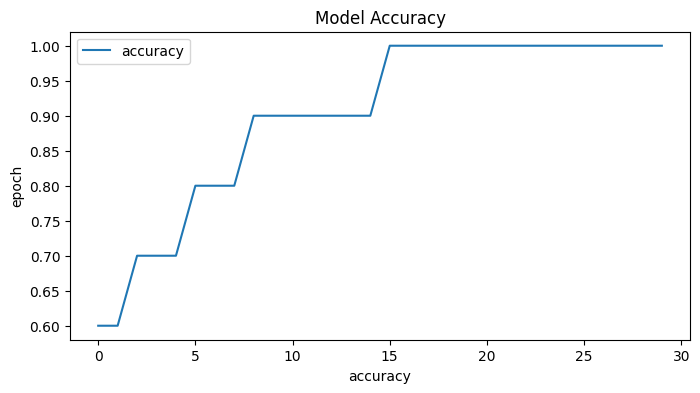

In [31]:
#6.시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'],label='accuracy')
plt.title("Model Accuracy")
plt.ylabel('epoch')
plt.xlabel('accuracy')
plt.legend()
plt.show()

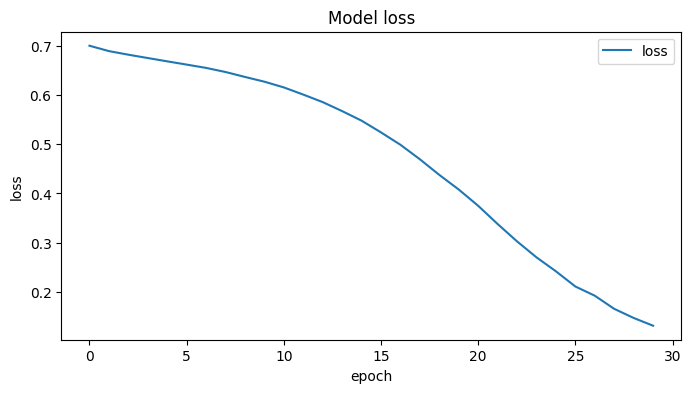

In [24]:
#손실 그래프
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],label='loss')
plt.title("Model loss")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [27]:
#모델 평가
loss, accuracy= model.evaluate(X,y)
print(f"훈련데이터의 손실:{loss:.4f},정확도:{accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.1210
훈련데이터의 손실:0.1210,정확도:1.0000


In [ ]:
#모델 저장하기
model.save("../Data/rnn_sentiment_model.keras")

In [30]:
#fastapi
#모델 불러오기
from tensorflow.keras.models import load_model
load_model=load_model("../Data/rnn_sentiment_model.keras")

In [ ]:
pred

In [35]:
#불러온 모델로 예측하기
test_sentence=['i love movie']
test_seq= tokenizer.texts_to_sequences(test_sentence)
test_pad=pad_sequences(test_seq,maxlen=max_len,padding='post')
pred=load_model.predict(test_pad)[0][0]
print(f"임력문장:{test_sentences[0]}")
print(f"긍정확률:{pred:.4f}")
print("예측결과:긍정" if pred >= 0.5 else "예측결과:부정")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
임력문장:i love it
긍정확률:0.8622
예측결과:긍정
